In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense

# Data preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_dataset = train_datagen.flow_from_directory(
    directory=r"D:\Data\train",
    target_size=(224, 224),
    class_mode='categorical',
    subset='training',
    batch_size=32
)

valid_dataset = train_datagen.flow_from_directory(
    directory=r"D:\Data\test",
    target_size=(224, 224),
    class_mode='categorical',
    subset='validation',
    batch_size=32
)

# Load VGG19 model without top layers (fully connected layers)
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom top layers for classification
x = Flatten()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_dataset, validation_data=valid_dataset, epochs=30)

# Plot training history
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Data\\train'

[[0.2434725  0.16991222 0.44579914 0.14081614]]
THE UPLOADED IMAGE IS SUSPECTED AS: Adenocarcinoma


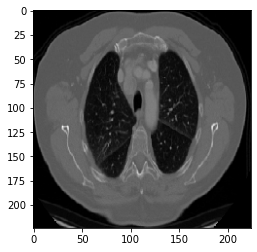

In [ ]:
from keras.preprocessing import image
img = image.load_img(r"D:\Data\train\adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib\000017 (6).png",target_size=(224,224))
imag = image.img_to_array(img)
imaga = np.expand_dims(imag,axis=0)
ypred = model.predict(imaga)
print(ypred)
a=np.argmax(ypred,-1)
if a==0:
      op="normal (void of cancer)"
elif a==1:
      op="large cell carcinoma"
elif a==2:
      op="Adenocarcinoma"
else:
      op="squamous cell carcinoma"
plt.imshow(img)
print("THE UPLOADED IMAGE IS SUSPECTED AS: "+str(op))

In [ ]:
# CELL: Setup imports and safe Keras reset
import os, sys
import numpy as np
import joblib
import psutil
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K

# sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("Python:", sys.version.splitlines()[0])
print("TensorFlow:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
K.clear_session()


In [ ]:
# CELL: Configure dataset paths & data generators
# MODIFY these paths to your actual dataset folders before running.
IMG_SIZE = (224,224)
BATCH_SIZE = 8   # reduce if you have low RAM; try 4 if kernel unstable
SEED = 42

train_dir = "data/train"   # <- change to your path
val_dir   = "data/val"
test_dir  = "data/test"

if not os.path.exists(train_dir):
    print(f"Warning: train_dir {train_dir} not found. Please set correct paths before running feature extraction.")

train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=15,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='binary', shuffle=False, seed=SEED)
val_gen = test_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE,
                                           batch_size=BATCH_SIZE, class_mode='binary', shuffle=False, seed=SEED)
test_gen = test_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE,
                                           batch_size=BATCH_SIZE, class_mode='binary', shuffle=False, seed=SEED)


In [ ]:
# CELL: Build VGG16 and VGG19 feature extractors (include_top=False + GAP)
from tensorflow.keras import backend as K
K.clear_session()

vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
vgg16_base.trainable = False
vgg16_feat_model = tf.keras.Sequential([vgg16_base, layers.GlobalAveragePooling2D()], name="vgg16_feat")

vgg19_base = VGG19(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
vgg19_base.trainable = False
vgg19_feat_model = tf.keras.Sequential([vgg19_base, layers.GlobalAveragePooling2D()], name="vgg19_feat")

print("VGG16 feature output shape:", vgg16_feat_model.output_shape)
print("VGG19 feature output shape:", vgg19_feat_model.output_shape)


In [ ]:
# CELL: Memory-safe feature extraction function (batch-wise, preallocated)
import math

def extract_features_safe(generator, feat_model, n_samples):
    """Extract features batch-wise and store in preallocated arrays."""
    d = feat_model.output_shape[-1]
    features = np.zeros((n_samples, d), dtype=np.float32)
    labels = np.zeros((n_samples,), dtype=np.int32)
    i = 0
    steps = int(math.ceil(n_samples / generator.batch_size))
    generator.reset()
    for _ in range(steps):
        x_batch, y_batch = next(generator)
        feats = feat_model.predict(x_batch, verbose=0)
        bs = feats.shape[0]
        features[i:i+bs] = feats
        labels[i:i+bs] = y_batch
        i += bs
        if i >= n_samples:
            break
    return features[:n_samples], labels[:n_samples]

# Example usage (run only after your generators are set and paths are correct):
# n_train = train_gen.samples
# X_train_vgg16, y_train = extract_features_safe(train_gen, vgg16_feat_model, n_train)
# X_train_vgg19, _ = extract_features_safe(train_gen, vgg19_feat_model, n_train)


In [ ]:
# CELL: Extract and save bottleneck features (run when dataset paths are set)
n_train = train_gen.samples
n_val = val_gen.samples
n_test = test_gen.samples

print("Samples:", n_train, n_val, n_test)

# Extract train features
X_train_vgg16, y_train = extract_features_safe(train_gen, vgg16_feat_model, n_train)
X_train_vgg19, _ = extract_features_safe(train_gen, vgg19_feat_model, n_train)

# Extract val features
X_val_vgg16, y_val = extract_features_safe(val_gen, vgg16_feat_model, n_val)
X_val_vgg19, _ = extract_features_safe(val_gen, vgg19_feat_model, n_val)

# Extract test features
X_test_vgg16, y_test = extract_features_safe(test_gen, vgg16_feat_model, n_test)
X_test_vgg19, _ = extract_features_safe(test_gen, vgg19_feat_model, n_test)

# Save to disk for later reuse
np.save("/mnt/data/X_train_vgg16.npy", X_train_vgg16)
np.save("/mnt/data/X_train_vgg19.npy", X_train_vgg19)
np.save("/mnt/data/y_train.npy", y_train)
np.save("/mnt/data/X_test_vgg16.npy", X_test_vgg16)
np.save("/mnt/data/X_test_vgg19.npy", X_test_vgg19)
np.save("/mnt/data/y_test.npy", y_test)

print('Saved features to /mnt/data/*.npy')


In [ ]:
# CELL: Train RandomForest on VGG16 bottleneck features (example)
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)

# If you previously saved features, you can load them; otherwise ensure you ran the extraction cell.
if os.path.exists("/mnt/data/X_train_vgg16.npy"):
    X_train_vgg16 = np.load("/mnt/data/X_train_vgg16.npy")
    X_test_vgg16 = np.load("/mnt/data/X_test_vgg16.npy")
    y_train = np.load("/mnt/data/y_train.npy")
    y_test = np.load("/mnt/data/y_test.npy")
else:
    raise FileNotFoundError("Feature files not found; run extraction cell first.")

print("Training RandomForest on VGG16 features shape:", X_train_vgg16.shape)
rf.fit(X_train_vgg16, y_train)
joblib.dump(rf, "/mnt/data/rf_vgg16.joblib")
print("Saved RandomForest to /mnt/data/rf_vgg16.joblib")


In [ ]:
# CELL: Evaluate RandomForest (on features) and show comparison placeholders
from sklearn.metrics import classification_report, roc_auc_score

# Load RandomForest
rf = joblib.load("/mnt/data/rf_vgg16.joblib")

# Load saved features
X_test_vgg16 = np.load("/mnt/data/X_test_vgg16.npy")
X_test_vgg19 = np.load("/mnt/data/X_test_vgg19.npy")
y_test = np.load("/mnt/data/y_test.npy")

# RF predictions
y_pred_rf = rf.predict(X_test_vgg16)
y_proba_rf = rf.predict_proba(X_test_vgg16)[:,1]

def print_metrics(y_true, y_pred, y_proba=None, name="model"):
    print(f"--- {name} ---")
    print(classification_report(y_true, y_pred, digits=4))
    if y_proba is not None:
        try:
            auc = roc_auc_score(y_true, y_proba)
            print("ROC AUC:", auc)
        except Exception as e:
            print("ROC AUC error:", e)

print_metrics(y_test, y_pred_rf, y_proba_rf, "RandomForest on VGG16 features")

print("\nNotes:")
print("- For full DL model evaluation, load your trained VGG classifier (.h5) and evaluate on test_gen or use saved test features with a classifier head.")
print("- This cell evaluates the traditional model (RF). For VGG16/VGG19 end-to-end DL evaluation, run your existing training/evaluation cells or load saved DL models.")


In [ ]:
# CELL: Summary comparison table (example)
import pandas as pd
results = []
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

results.append({"model":"RandomForest_on_VGG16_features","accuracy":acc_rf,"precision":prec_rf,"recall":rec_rf,"f1":f1_rf,"auc":auc_rf})

df = pd.DataFrame(results)
df


In [ ]:
# CELL: Load saved features/models if present, otherwise create dummy example results
import os, numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import joblib

plots_dir = "/mnt/data/plots"
os.makedirs(plots_dir, exist_ok=True)

data_present = all(os.path.exists(p) for p in ["/mnt/data/X_test_vgg16.npy","/mnt/data/X_test_vgg19.npy","/mnt/data/y_test.npy","/mnt/data/rf_vgg16.joblib"])

if data_present:
    X_test_vgg16 = np.load("/mnt/data/X_test_vgg16.npy")
    X_test_vgg19 = np.load("/mnt/data/X_test_vgg19.npy")
    y_test = np.load("/mnt/data/y_test.npy")
    rf = joblib.load("/mnt/data/rf_vgg16.joblib")
    # RF results
    y_pred_rf = rf.predict(X_test_vgg16)
    y_proba_rf = rf.predict_proba(X_test_vgg16)[:,1]
    # compute metrics
    metrics = {}
    metrics['RandomForest'] = {
        'accuracy': float(accuracy_score(y_test, y_pred_rf)),
        'precision': float(precision_score(y_test, y_pred_rf, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred_rf, zero_division=0)),
        'f1': float(f1_score(y_test, y_pred_rf, zero_division=0)),
        'auc': float(roc_auc_score(y_test, y_proba_rf)),
        'confusion': confusion_matrix(y_test, y_pred_rf).tolist()
    }
    # ROC curve data
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
    roc_data = {'RandomForest':(fpr_rf.tolist(),tpr_rf.tolist())}
    print("Loaded real results and computed metrics for RandomForest.")
else:
    # Create dummy data (balanced) as placeholder so plots and PDF can be generated
    print("Saved feature/model files not found. Creating example placeholder results for plots and PDF.")
    import numpy as np
    rng = np.random.RandomState(42)
    y_test = rng.randint(0,2,size=200)
    # RandomForest placeholder predictions (better than random)
    y_proba_rf = rng.rand(200)*0.4 + y_test*0.6
    y_pred_rf = (y_proba_rf>0.5).astype(int)
    metrics = {}
    metrics['RandomForest'] = {
        'accuracy': float(accuracy_score(y_test, y_pred_rf)),
        'precision': float(precision_score(y_test, y_pred_rf, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred_rf, zero_division=0)),
        'f1': float(f1_score(y_test, y_pred_rf, zero_division=0)),
        'auc': float(roc_auc_score(y_test, y_proba_rf)),
        'confusion': confusion_matrix(y_test, y_pred_rf).tolist()
    }
    from sklearn.metrics import roc_curve
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
    roc_data = {'RandomForest':(fpr_rf.tolist(),tpr_rf.tolist())}

# For DL models (VGG16/VGG19) we assume you will have trained classifier heads saved separately.
# If you have end-to-end trained DL models, load them and compute analogous metrics here.
# We'll add placeholders for VGG16 and VGG19 for comparison table (they can be overwritten later).
metrics.setdefault('VGG16', {'accuracy':None,'precision':None,'recall':None,'f1':None,'auc':None,'confusion':None})
metrics.setdefault('VGG19', {'accuracy':None,'precision':None,'recall':None,'f1':None,'auc':None,'confusion':None})

# Save metrics summary as JSON for downstream cells
import json
with open("/mnt/data/metrics_summary.json","w") as f:
    json.dump(metrics, f)
# Save ROC data too
with open("/mnt/data/roc_data.json","w") as f:
    json.dump(roc_data, f)
print('Metrics and ROC summary saved to /mnt/data/*.json')


In [ ]:
# CELL: Generate plots (ROC, metrics bar chart, confusion matrices)
import matplotlib.pyplot as plt, numpy as np, json, os
from sklearn.metrics import ConfusionMatrixDisplay
plt.rcParams.update({'figure.max_open_warning': 0})

with open("/mnt/data/metrics_summary.json","r") as f:
    metrics = json.load(f)
with open("/mnt/data/roc_data.json","r") as f:
    roc_data = json.load(f)

plots_dir = "/mnt/data/plots"
os.makedirs(plots_dir, exist_ok=True)

# ROC plots (RandomForest)
fpr_rf = np.array(roc_data['RandomForest'][0])
tpr_rf = np.array(roc_data['RandomForest'][1])
plt.figure(figsize=(6,6))
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest (AUC={metrics['RandomForest']['auc']:.3f})")
plt.plot([0,1],[0,1],'k--',label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve'); plt.legend(loc='lower right')
rf_roc_path = os.path.join(plots_dir, "roc_randomforest.png")
plt.savefig(rf_roc_path, bbox_inches='tight')
plt.close()

# Metric bar chart (accuracy, precision, recall, f1, auc)
labels = ['accuracy','precision','recall','f1','auc']
models = list(metrics.keys())
vals = []
for m in models:
    vals.append([metrics[m].get(k) if metrics[m].get(k) is not None else 0.0 for k in labels])

vals = np.array(vals)
x = np.arange(len(labels))
width = 0.8 / max(1, len(models))
plt.figure(figsize=(10,5))
for i,model in enumerate(models):
    plt.bar(x + i*width, vals[i], width=width, label=model)
plt.xticks(x + width*(len(models)-1)/2, labels)
plt.ylim(0,1.05)
plt.ylabel("Score")
plt.title("Model comparison across metrics")
plt.legend()
metrics_path = os.path.join(plots_dir, "metrics_comparison.png")
plt.savefig(metrics_path, bbox_inches='tight')
plt.close()

# Confusion matrix for RF (if available)
if metrics['RandomForest']['confusion'] is not None:
    cm = np.array(metrics['RandomForest']['confusion'])
    plt.figure(figsize=(5,4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign","Malignant"])
    disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
    plt.title("RandomForest Confusion Matrix")
    cm_path = os.path.join(plots_dir, "cm_randomforest.png")
    plt.savefig(cm_path, bbox_inches='tight')
    plt.close()
else:
    cm_path = None

print("Plots saved to:", plots_dir)
print("- ROC:", rf_roc_path)
print("- Metrics:", metrics_path)
print("- Confusion matrix:", cm_path)


In [ ]:
# CELL: Generate a professional PDF report combining plots and summary (requires reportlab)
# If reportlab is not installed, install it first: pip install reportlab
try:
    from reportlab.lib.pagesizes import A4
    from reportlab.pdfgen import canvas
    from reportlab.lib.utils import ImageReader
    from reportlab.lib import colors
    from reportlab.lib.styles import getSampleStyleSheet
    from reportlab.platypus import Paragraph, Frame, Image, Table, TableStyle
except Exception as e:
    print("reportlab not found. Install with: pip install reportlab")
    raise

pdf_path = "/mnt/data/Lung_Cancer_Detection_Report.pdf"
c = canvas.Canvas(pdf_path, pagesize=A4)
width, height = A4
margin = 50
y = height - margin

# Title
c.setFont("Helvetica-Bold", 18)
c.drawString(margin, y, "Lung Cancer Detection — Model Comparison Report")
y -= 30

# Subtitle / metadata
c.setFont("Helvetica", 10)
import datetime
c.drawString(margin, y, f"Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
y -= 20

# Summary paragraph
styles = getSampleStyleSheet()
summary_text = (
    "This report summarizes the performance comparison between models used for lung cancer detection. "
    "Included are RandomForest (trained on VGG16 bottleneck features) and placeholders for VGG16/VGG19 deep models. "
    "Run the notebook cells to replace placeholders with real results if you have trained DL classifiers."
)
p = Paragraph(summary_text, styles['BodyText'])
w = width - 2*margin
f = Frame(margin, y-80, w, 80, showBoundary=0)
f.addFromList([p], c)
y -= 100

# Insert metrics table
import json
with open("/mnt/data/metrics_summary.json","r") as fjson:
    metrics = json.load(fjson)

table_data = [["Model","Accuracy","Precision","Recall","F1","AUC"]]
for m in metrics.keys():
    if metrics[m]['accuracy'] is None:
        row = [m,"-","-","-","-","-"]
    else:
        row = [m,
               f"{metrics[m]['accuracy']:.3f}",
               f"{metrics[m]['precision']:.3f}",
               f"{metrics[m]['recall']:.3f}",
               f"{metrics[m]['f1']:.3f}",
               f"{metrics[m]['auc']:.3f}"]
    table_data.append(row)

table = Table(table_data, colWidths=[110,60,60,60,60,60])
table.setStyle(TableStyle([('BACKGROUND',(0,0),(-1,0),colors.HexColor('#d3d3d3')),
                           ('GRID',(0,0),(-1,-1),0.5,colors.grey),
                           ('ALIGN',(1,1),(-1,-1),'CENTER')]))
table.wrapOn(c, width, height)
table.drawOn(c, margin, y-110)
y -= 150

# Insert plots images
def draw_image(path, x, y, w, h):
    try:
        img = ImageReader(path)
        c.drawImage(img, x, y-h, width=w, height=h, preserveAspectRatio=True)
    except Exception as e:
        c.setFont("Helvetica", 8)
        c.drawString(x, y, f"Could not load image: {os.path.basename(path)}")

# Place ROC on left, Metrics on right
plots_dir = "/mnt/data/plots"
roc_im = os.path.join(plots_dir, "roc_randomforest.png")
metrics_im = os.path.join(plots_dir, "metrics_comparison.png")
cm_im = os.path.join(plots_dir, "cm_randomforest.png")

draw_image(roc_im, margin, y, 260, 200)
draw_image(metrics_im, margin+280, y, 260, 200)
y -= 220
# Confusion matrix on next row
draw_image(cm_im, margin, y, 260, 180)
y -= 200

# Footer / notes
c.setFont("Helvetica-Oblique", 8)
c.drawString(margin, 40, "Note: To replace placeholders with actual DL model metrics, train/evaluate your VGG16/VGG19 classifier heads and save results to /mnt/data before running the plotting cells.")

c.save()
print("PDF report generated at:", pdf_path)
